# **Notebook 7 – Outlier Analysis**

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load dataset
df = pd.read_csv("healthcare_patient_dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PatientID      1500 non-null   object 
 1   Age            1500 non-null   int64  
 2   Gender         1500 non-null   object 
 3   Height_cm      1500 non-null   float64
 4   Weight_kg      1500 non-null   float64
 5   BMI            1500 non-null   float64
 6   HeartRate      1500 non-null   int64  
 7   SystolicBP     1500 non-null   int64  
 8   DiastolicBP    1500 non-null   int64  
 9   BloodGlucose   1500 non-null   int64  
 10  Cholesterol    1500 non-null   int64  
 11  Temperature_C  1500 non-null   float64
 12  HospitalDays   1500 non-null   int64  
 13  Diagnosis      1500 non-null   object 
dtypes: float64(4), int64(7), object(3)
memory usage: 164.2+ KB


## **1. What is an Outlier?**



**Understand the Concept**

An outlier is a data value that is significantly different from most other values in a dataset.




**Demonstrate the Concept**

some records may contain unusually high, unusually low, or invalid values. These values can be investigated as potential outliers.

**Real-Life Example**

- If most patient ages are between 18 and 90, but one record has 250
- This value is a potential outlier and should be investigated.
- Similarly, a negative weight or an extremely high body temperature may indicate a possible data-entry error.

**AI/ML Usage**

Outliers can affect:

- Mean and standard deviation
- Data distribution
- Statistical analysis
- Regression models
- Machine Learning model performance

However, **not every outlier should be removed**. Some unusual values may represent genuine patient observations and contain useful information.

In [4]:
# statistics for numerical col
df.select_dtypes(include="number").describe()

,Age,Height_cm,Weight_kg,BMI,HeartRate,SystolicBP,DiastolicBP,BloodGlucose,Cholesterol,Temperature_C,HospitalDays
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,49.116000,165.040200,71.497800,26.547467,75.612667,121.996667,78.208667,107.652000,195.458667,36.835467,3.133333
std,17.150004,10.758714,14.950889,6.473128,12.197069,16.868304,11.100418,26.536196,35.027678,0.862538,2.003222
min,18.000000,18.000000,-12.000000,10.600000,45.000000,85.000000,-5.000000,60.000000,110.000000,35.500000,0.000000
25%,37.000000,158.100000,61.475000,22.200000,68.000000,110.000000,71.000000,89.000000,173.000000,36.500000,2.000000
50%,49.000000,165.150000,71.850000,26.000000,75.000000,121.000000,78.000000,107.000000,195.000000,36.800000,3.000000
75%,60.000000,171.825000,81.400000,30.600000,84.000000,133.000000,85.000000,125.000000,218.000000,37.100000,4.000000
max,250.000000,195.000000,138.000000,50.800000,145.000000,225.000000,115.000000,310.000000,420.000000,65.000000,38.000000


**Interpretation**

- The describe function provides summary statistics for numerical columns.
- Very high maximum values or very low minimum values may indicate potential outliers.
- These unusual values should be investigated using outlier detection techniques.

## **2. Why Outliers Occur**



**Understand the Concept**

Outliers can occur due to:

- Data-entry errors
- Measurement errors
- System errors
- Genuine extreme observations
- Natural variation



**Demonstrate the Concept**

**Real-Life Example**

An extremely high BloodGlucose value may represent a real patient condition, while a negative weight is likely a data-entry error.

**AI/ML Usage**

Understanding the cause helps decide whether an outlier should be corrected, removed, transformed, or retained.

In [5]:
invalid_records = df[(df["Age"] > 100) | (df["Weight_kg"] <= 0) |
                     (df["Height_cm"] < 50) | (df["Temperature_C"] > 45) | (df["DiastolicBP"] <= 0)]
print(invalid_records)

     PatientID  Age  Gender  Height_cm  Weight_kg   BMI  HeartRate  \
73    PAT00074  250  Female      170.9       69.7  23.9         97   
356   PAT00357   48  Female       18.0       77.2  31.3         72   
721   PAT00722   19  Female      181.3      -12.0  24.2         93   
1108  PAT01109   37  Female      167.8       70.8  25.1         82   
1421  PAT01422   66    Male      156.9       61.7  25.1         84   

      SystolicBP  DiastolicBP  BloodGlucose  Cholesterol  Temperature_C  \
73           111           88           116          135           36.8   
356          153           71           132          154           36.7   
721           94           63           153          207           36.5   
1108         148           62           126          174           65.0   
1421         100           -5           120          206           36.6   

      HospitalDays              Diagnosis  
73               1        Healthy Checkup  
356              4  Respiratory Infectio

**Interpretation**

- The output shows records with invalid values.
- These values are likely data-entry errors.
- They should be checked before analysis.
- Genuine extreme values should not be removed automatically.

## **3. Types of Outliers**

Outliers can be divided into two main types:

- Univariate Outliers
- Multivariate Outliers

### **3.1 Univariate Outliers**

**Understand the Concept**

A univariate outlier is an unusual value in a single variable.

**Demonstrate the Concept**

**Real-Life Example**

A patient with a very high BloodGlucose value may be identified as a univariate outlier.

**AI/ML Usage**

Univariate outliers can affect data distribution and statistical calculations.

**Interpretation**

- The output shows unusual values in the BloodGlucose column.
- These values are identified by analyzing one variable at a time.

In [6]:
# univariate outliers - BloodGlucose

q1 = df["BloodGlucose"].quantile(0.25)
q3 = df["BloodGlucose"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

univariate_outliers = df[(df["BloodGlucose"] < lower_bound) |(df["BloodGlucose"] > upper_bound)]
print(univariate_outliers[["PatientID", "BloodGlucose"]])

    PatientID  BloodGlucose
37   PAT00038           310
569  PAT00570           190
645  PAT00646           228
739  PAT00740           180
841  PAT00842           182
965  PAT00966           186


### **3.2 Multivariate Outliers**

**Understand the Concept**

A multivariate outlier is an unusual combination of two or more variables.

**Demonstrate the Concept**


**Real-Life Example**

A patient with Age = 24, BloodGlucose = 228, and Cholesterol = 330 may represent an unusual combination.

**AI/ML Usage**

Multivariate outliers help identify unusual patterns that cannot be detected by analyzing a single variable.

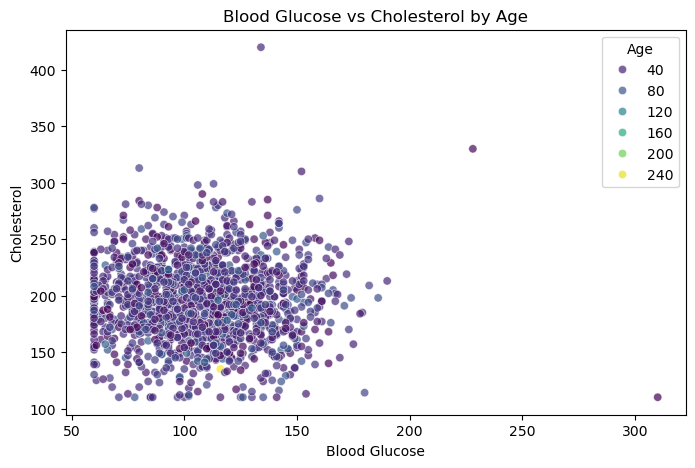

In [7]:
# Visualization - multivariate outliers

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="BloodGlucose", y="Cholesterol", hue="Age", palette="viridis", alpha=0.7)
plt.title("Blood Glucose vs Cholesterol by Age")
plt.xlabel("Blood Glucose")
plt.ylabel("Cholesterol")
plt.show()

**Interpretation**

- The scatter plot shows the relationship between multiple variables.
- Unusual combinations of BloodGlucose, Cholesterol, and Age may indicate multivariate outliers.

## **4. Detection Techniques**

Outliers can be detected using statistical methods and visualizations.

The techniques are:

- IQR Method
- Z-Score Method
- Box Plot
- Scatter Plot

### **4.1 IQR Method**

**Understand the Concept**

The IQR method identifies values that fall below or above a specific range.

Values outside the lower and upper bounds are considered potential outliers.

**Real-Life Example**

We use BloodGlucose to identify unusually high or low patient values.

**AI/ML Usage**

The IQR method is useful for detecting outliers in skewed data.

In [13]:
# IQR Method
q1 = df["BloodGlucose"].quantile(0.25)
q3 = df["BloodGlucose"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
iqr_outliers = df[(df["BloodGlucose"] < lower_bound) | (df["BloodGlucose"] > upper_bound)]
print(iqr_outliers[["PatientID", "BloodGlucose"]])

    PatientID  BloodGlucose
37   PAT00038           310
569  PAT00570           190
645  PAT00646           228
739  PAT00740           180
841  PAT00842           182
965  PAT00966           186


**Interpretation**

- The output shows potential outliers in BloodGlucose.
- Values outside the calculated range are flagged as outliers.

### **4.2 Z-Score Method**

**Understand the Concept**

- The Z-Score shows how far a value is from the mean in terms of standard deviations.
- Values with an absolute Z-Score greater than 3 are commonly considered potential outliers.

**Real-Life Example**

We use Cholesterol values to identify extreme observations.

**AI/ML Usage**

The Z-Score method is useful when data is approximately normally distributed.

In [12]:
# Z-Score method
from scipy import stats
z_scores = np.abs(stats.zscore(df["Cholesterol"]))
z_outliers = df[z_scores > 3]
print(z_outliers[["PatientID", "Cholesterol"]])

    PatientID  Cholesterol
184  PAT00185          420
222  PAT00223          313
348  PAT00349          310
645  PAT00646          330


**Interpretation**

- The output shows Cholesterol values with a Z-Score greater than 3.
- These observations are considered potential outliers.

### **4.3 Box Plot**

**Understand the Concept**

A box plot visually shows the distribution of a numerical variable and highlights potential outliers.

**Real-Life Example**

We visualize BloodGlucose values to identify unusual observations.

**AI/ML Usage**

Box plots provide a quick visual method for detecting outliers.

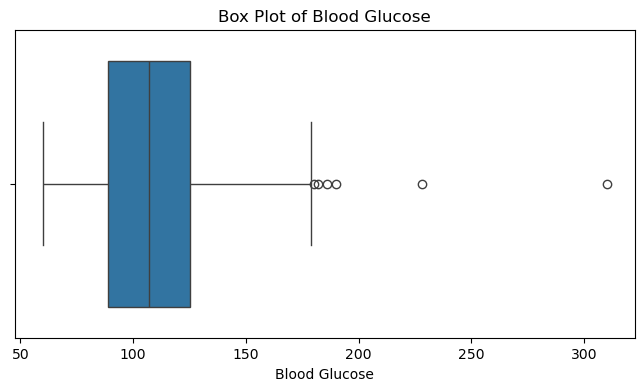

In [14]:
# Box Plot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["BloodGlucose"])
plt.title("Box Plot of Blood Glucose")
plt.xlabel("Blood Glucose")
plt.show()

**Interpretation**

- Points outside the main range may represent potential outliers.
- The box plot makes unusual values easy to identify visually.

### **4.4 Scatter Plot**

**Understand the Concept**

A scatter plot helps identify unusual observations by comparing two numerical variables.

**Real-Life Example**

We compare BloodGlucose and Cholesterol values.

**AI/ML Usage**

Scatter plots help identify unusual relationships and multivariate outliers.

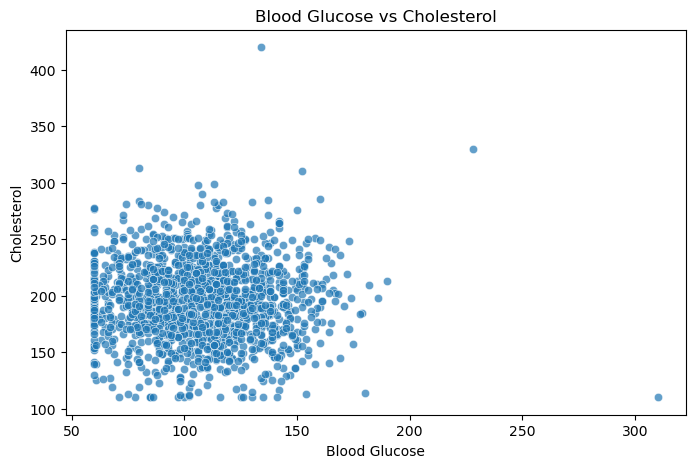

In [15]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="BloodGlucose", y="Cholesterol", alpha=0.7)
plt.title("Blood Glucose vs Cholesterol")
plt.xlabel("Blood Glucose")
plt.ylabel("Cholesterol")
plt.show()

**Interpretation**

- Most observations form the general pattern of the data.
- Points far from this pattern may represent potential multivariate outliers.

## **5. Outlier Evaluation & Treatment Decisions**

After detecting outliers, we should evaluate them before taking any action.

Do not automatically remove every outlier.

### **5.1 Is it a Genuine Observation?**

**Understand the Concept**

Check whether the unusual value represents a real patient observation.

**For example:**

BloodGlucose = 310 may be extreme but can represent a genuine medical condition.

### **5.2 Is it a Data-Entry Error?**

**Understand the Concept**

Check whether the value is impossible or caused by an input error.

**For example:**

- Age = 250
- Weight_kg = -12
- Temperature_C = 65

These values are likely data-entry errors.

### **5.3 Is it an Unusual but Valid Observation?**

**Understand the Concept**

Some values may be unusual but still valid.

For example:

- Very high Cholesterol
- High SystolicBP
- High HeartRate
- Long HospitalDays

These values may represent genuine patient conditions.

### **5.4 Should it be Removed?**

**Understand the Concept**

Remove an outlier only when there is strong evidence that it is incorrect or invalid.

For example, negative Weight_kg can be treated as invalid data.

### **5.5 Should it be Transformed?**

**Understand the Concept**

If an extreme value is valid but affects the data distribution, transformation can be considered.

Common approaches include:

- Log transformation
- Square root transformation
- Capping extreme values

In [16]:
# Log transformation for BloodGlucose
df["BloodGlucose_Log"] = np.log1p(df["BloodGlucose"])
df[["BloodGlucose", "BloodGlucose_Log"]].head()

,BloodGlucose,BloodGlucose_Log
0,136,4.919981
1,75,4.330733
2,137,4.927254
3,90,4.510860
4,118,4.779123


### **5.6 Should it be Retained?**

**Understand the Concept**

Valid outliers may contain important information and should be retained.

example: a patient with very high BloodGlucose may represent a real medical condition.

In [17]:
# potential invalid values

potential_errors = df[(df["Age"] > 100) | (df["Weight_kg"] <= 0) |  (df["Height_cm"] < 50) |
                      (df["Temperature_C"] > 45) | (df["DiastolicBP"] <= 0)]
print(potential_errors)

     PatientID  Age  Gender  Height_cm  Weight_kg   BMI  HeartRate  \
73    PAT00074  250  Female      170.9       69.7  23.9         97   
356   PAT00357   48  Female       18.0       77.2  31.3         72   
721   PAT00722   19  Female      181.3      -12.0  24.2         93   
1108  PAT01109   37  Female      167.8       70.8  25.1         82   
1421  PAT01422   66    Male      156.9       61.7  25.1         84   

      SystolicBP  DiastolicBP  BloodGlucose  Cholesterol  Temperature_C  \
73           111           88           116          135           36.8   
356          153           71           132          154           36.7   
721           94           63           153          207           36.5   
1108         148           62           126          174           65.0   
1421         100           -5           120          206           36.6   

      HospitalDays              Diagnosis  BloodGlucose_Log  
73               1        Healthy Checkup          4.762174  
356 

**Interpretation**

- Invalid values should be corrected or removed after verification.
- Unusual but valid observations should usually be retained.
- Valid extreme values may be transformed if they strongly affect the data distribution.